In [1]:
# %matplotlib widget
import scipy
import numpy as np
import matplotlib.pyplot as plt
import symengine
from astropy import units as u
from astropy import constants as const
from astropy.units import Quantity
from astropy.visualization import quantity_support
from mpl_toolkits.mplot3d import Axes3D 
import mpl_toolkits.mplot3d as m3d
import time
import os
import matplotlib.animation as animation
quantity_support()
%matplotlib widget

### Tuesday, Jan 20

In [ ]:
def quad(x):
    return x**2 + 0.7 * x - 3

def first_der(x):
    return 2 * x + 0.7

initial = time.time()

tolerance = 0.0001
x0 = 0.3
err = 1
x1 = 1
while err > tolerance:
    x1 = x0 - (quad(x0)/first_der(x0))
    err = quad(x1)-quad(x0)
    x0=x1

print(time.time()-initial,x1)

In [ ]:
initial = time.time()
scipy.optimize.newton(quad,x0 = 1, fprime = first_der,rtol = 0.0001,full_output=True)
#print(time.time()-initial)

In [ ]:
def equations(p):
    x,y = p
    return (x+y**2-4,np.exp(x)+x*y-3)

x,y=scipy.optimize.fsolve(equations,(1,1))
equations((x,y))

In [ ]:
a = np.array([(2,4),(5,1)])
a
b = np.mean(((np.invert(a))**2).T)
b

In [ ]:
randarray = np.random.rand(1,50)
print(randarray)

np.random.seed(0)
target = np.random.random()
print(target)
index = (np.abs(target-randarray)).argmin()
print(index)
randarray[0,index]


In [ ]:
a = np.array([(1,2),(3,4)])
def inversion(A):
    inverter = 1/((A[0,0]*A[1,1])-(A[0,1]*A[1,0]))
    intermed = np.array([ (A[1,1],-A[0,1]),(-A[1,0],A[0,0])])
    return inverter * intermed

print(inversion(a))

print(np.invert(a))

In [ ]:
time_array = []
n = [2,3,4,5,6,7,8,9,10]
for size in range(2,10):
    print(size)
    array = np.random.rand(size,size)
    print(array)
    initial= time.time()
    inverted = inv(array)
    total_time = time.time()-initial
    time_array.append(total_time)

plt.plot(n,time_array)

### Thursday Jan 22

In [12]:
initial = time.time()
f = lambda x: np.sin(x**2+x)

N = 10000
upper = 4
lower = 0
first_deriv = lambda x: (2*x + 1) * np.cos(x**2 + x)
def trap_rule(f,lower,upper,N,first_deriv):
    grid = np.linspace(lower,upper,N)
    gridspacing = grid[2]-grid[1]
    integral = 0
    for i in range(1,len(grid)-1):
        integral +=  ( ( f(grid[i-1])+f(grid[i]))/2 ) * gridspacing
    error = (upper-lower)**2/(12 * N ** 2) * (first_deriv(upper)-first_deriv(lower))
    return integral, error

print("manual trapezoidal rule took ", time.time()-initial," seconds to find ", trap_rule(f,lower,upper,N,first_deriv))

print("scipy quad took ", time.time()-initial," seconds to find ",scipy.integrate.quad(f,lower,upper))

grid = np.linspace(lower,upper,N)
f2 = np.sin(grid**2 + grid)

print("scipy trapezoidal rule took ", time.time()-initial," seconds to find ", scipy.integrate.trapezoid(f2,grid))
print("scipy simpson rule took ", time.time()-initial," seconds to find ",scipy.integrate.simpson(f2,grid))


manual trapezoidal rule took  0.0016345977783203125  seconds to find  (np.float64(0.486769337861152), np.float64(3.5636514084273704e-08))
scipy quad took  0.05759429931640625  seconds to find  (0.4871342217916623, 9.885782822732409e-12)
scipy trapezoidal rule took  0.05928468704223633  seconds to find  0.487134257435317
scipy simpson rule took  0.059694528579711914  seconds to find  0.4871342217912405


In [ ]:
f = lambda x: x**3 + 3 * x ** 2 + x
grid = np.linspace(0,10,10000)

def simpsons(f,grid,h):
    x = f(grid)
    sum = 0
    for i in range(0,int(len(grid)/2)):
        sum += f(x[2*i-2]) + 4 * f(x[2*i-1]+f(x[2*i]))
    integral = h/3 * sum
    return integral

simpsons(f,grid,h=1)
f2 = grid**3 + 3 * grid ** 2 + grid
scipy.integrate.simpson(f2,grid)

In [ ]:
def ODE(x,y):
    y1 = y-x
    return y1
y0 = 1
h = 1
x0 = 0
x_f = 10
def RungeKutta(x,y,h,ODE):
    k1 = h* np.array(ODE(x,y))
    k2 = h *np.array( ODE(x+0.5*h,y+0.5 * k1))
    k3 = h *np.array( ODE(x+0.5*h,y+0.5 * k2))
    k4 = h * np.array( ODE(x+h,y+k3))
    y = y + (1/6 * k1) + (1/3 * k2) + (1/3 * k3) + (1/6 * k4)
    x = x+h
    return x,y


x = x0
y = y0
y_rk = [y0]
x_rk = [0]

while x <= x_f:
    x,y = RungeKutta(x,y,h,ODE)
    y_rk.append(y)
    x_rk.append(x)
plt.plot(x_rk,y_rk)

x_rk,y_rk

In [ ]:
y0=0
y_p0=1
x0=0
y=y0
a=2
b=2
c=2
d=2
h = 0.0001
x_end = 10
def system_coupled(x,Y):
    y1,y2 = Y
    y1_p = y2
    y2_p = (d-b*x**2*y2-c*x*y1)/a
    return [y1_p,y2_p]

x = x0
y = np.array([y0,y_p0])
y_rk = [y.copy()]
x_rk = [0]

while x <= x_end:
    x,y = RungeKutta(x,y,h,system_coupled)
    x = x+h
    y_rk.append(y.copy())
    x_rk.append(x)

y_rk=np.array(y_rk)
x_rk=np.array(x_rk)

plt.plot(x_rk,y_rk[:,0])

In [ ]:
# m1*x1_pp+b1*x1_p+k1(x1-L1)-k2(x2-x1-L2)=0
# x1_p=y1
# x1_pp = y1_p = -(b1*y1+k1(x1-L1)-k2(x2-x1-L2))/m1



# m2*x2_pp+b2*x2_p+k2(x2-x1-L2)=0
# x2_p = y2
# y2_p = x2_pp = -(b2*y2+k2(x2-x1-L2))/m2

def fourcouple(t,Z):
    x1,x2,y1,y2 = Z
    x1_p = y1
    x2_p = y2
    y1_p = -(b1*y1+k1*(x1-L1)-k2*(x2-x1-L2))/m1
    y2_p = -(b2*y2+k2*(x2-x1-L2))/m2
    return [x1_p,x2_p,y1_p,y2_p]

m1,m2,k1,k2,L1,L2,b1,b2 = 1,1.5,8,40,0.5,1,0.8,0.5

x10,x20 = 0.5,2.25
x=0
h=0.001
x_end = 20
Z = [x10,x20,0,0]

x_rk = [x]
Z_rk = [Z.copy()]



while x <= x_end:
    x,Z = RungeKutta(x,Z,h,fourcouple)
    Z_rk.append(Z.copy())
    x_rk.append(x)



plt.plot(x_rk, np.array(Z_rk)[:,0], label='x1')
plt.plot(x_rk, np.array(Z_rk)[:,1], label='x2')
plt.legend()
plt.title('Two Masses on Spring in Series')
plt.xlabel('Time (s)')
plt.ylabel('Position (x)')
plt.show()


plt.plot(x_rk, np.array(Z_rk)[:,0]-0.5, label='x1')
plt.plot(x_rk, np.array(Z_rk)[:,1]-1.5, label='x2')
plt.legend()
plt.title('Two Masses on Spring in Series')
plt.xlabel('Time (s)')
plt.ylabel('Position (x)')
plt.show()

In [ ]:
rsult = scipy.integrate.RK45(fourcouple,0,Z,t_bound=10)
rsult.step()


### Tues Jan 27th

In [ ]:
gravity_dat = np.loadtxt('/home/lkoo/projects/Practice/Resources/gravity.dat')
gravity_dat

In [ ]:
grid = np.linspace(0,10,100)

quad_array=[]
#trap_array = []
#simpson_array = []
analytic_sol = lambda t: np.exp(t)*(t**2 -2*t-1)+1
analytic_array = []
for x in grid:
    grid = np.linspace(0,x,100)
    G = lambda t: np.exp(t) * (t**2 -3)
    quad_array.append(scipy.integrate.quad(G,0,x)[0])
    analytic_array.append(analytic_sol(x))
    #trap_array.append(scipy.integrate.trapezoid(G,0,x)[0])
    #simpson_array.append(scipy.integrate.simpson(G,0,x)[0])

plt.plot(grid,quad_array, c='r',label='Scipy Sol')
plt.plot(grid,analytic_array, linestyle = '--',label='Analytic Sol')
plt.yscale('log')
plt.xlabel('x values')
plt.ylabel('y values')
plt.title('Integral function')
plt.legend()
plt.ylim(1e-2,1e7)


In [ ]:
def ODE(t,y):
    y1 = y * np.cos(x+y)
    return y1
y0 = 1
n = 10

factor = 1
t = np.linspace(0,10,n)
solved = scipy.integrate.odeint(ODE,y0,t)

plt.plot(t,solved[:,0],c = 'r', lw=3)
plt.scatter(t,solved[:,0],c='r',marker='*')

factor = 10
new_grid = np.linspace(0,10,n*factor)

new_sol = np.interp(new_grid,t,solved[:,0])

plt.plot(new_grid,new_sol,c = 'b', lw=1, alpha = 0.5)
plt.scatter(new_grid,new_sol,c='b',alpha = 0.5)

int_1,int_2 = [],[]

for res_scale in range(1,10):
    n = 10 * res_scale
    t = np.linspace(0,10,n)
    solved = scipy.integrate.odeint(ODE,y0,t)

    plt.plot(t,solved[:,0],c = 'r', lw=3)
    plt.scatter(t,solved[:,0],c='r',marker='*')

    factor = 10
    new_grid = np.linspace(0,10,n*factor)

    new_sol = np.interp(new_grid,t,solved[:,0])

    gridspacing = t[2]-t[1]
    integral = 0
    for i in range(1,len(t)-1):
        integral +=  ( ( solved[i-1])+solved[i])/2  * gridspacing

    int_1.append(integral)

    gridspacing = new_grid[2]-new_grid[1]
    integral = 0
    for i in range(1,len(new_grid)-1):
        integral +=  ( ( new_sol[i-1])+new_sol[i])/2  * gridspacing

    int_2.append(integral)


In [ ]:
int_1,int_2 = [],[]
res_scale = np.linspace(1,1000,100)
for scale in res_scale:
    n = int(10 * scale)
    t = np.linspace(0,10,n)
    solved = scipy.integrate.odeint(ODE,y0,t)

    factor = 10
    new_grid = np.linspace(0,10,n*factor)

    new_sol = np.interp(new_grid,t,solved[:,0])

    gridspacing = t[2]-t[1]
    integral = 0
    for i in range(1,len(t)-1):
        integral +=  ( ( solved[i-1])+solved[i])/2  * gridspacing

    int_1.append(integral)

    gridspacing = new_grid[2]-new_grid[1]
    integral = 0
    for i in range(1,len(new_grid)-1):
        integral +=  ( ( new_sol[i-1])+new_sol[i])/2  * gridspacing

    int_2.append(integral)


plt.plot(res_scale,int_1,label = 'Sparser')
plt.plot(res_scale,int_2, label = 'Factor of 10')
plt.title('Integral Value vs Resolution')
plt.xlabel('Resolution')
plt.ylabel('Integral')
plt.xscale('log')
plt.legend()

In [ ]:
res_scale

### Tues Feb 3

In [ ]:
def system(sys,t):
    x,y=sys
    x1=x*(2.-y-x)
    y1=-y*(1.-1.5*x)
    return [x1,y1]
#Define grid and initial conditions
t = np.linspace(0,200,1000)
init = [1.0,1.0]
#Solve for the system (both are solved simultaneously)
sol = scipy.integrate.odeint(system,init,t)
#Print out solutions and direct output to file
for i in range(0,len(sol)):
    print(t[i],sol[i][0],sol[i][1])


fig,ax = plt.subplots()
a=sol[:][0]
b=sol[:][1]
z1 = system([a,b],t)[0]
print(z1)
line1, = ax.plot(t[0], z1[0])
def update1(frame):
    x = t[:frame]
    y = z1[:frame]

    line1.set_data(t[:frame], z1[:frame])
    return line1,
ani = animation.FuncAnimation(fig, update1, frames=100, interval=50, blit=True)
plt.show()
#ani.save('test.mp4',fps=3)

In [ ]:
fig, ax = plt.subplots()
#Define function you wish to animate
def func(a, b, x):
    return a*x+b
#Define x-grid and corresponding
#y-grid based on the defined function
x = np.linspace(-5, 5, 100)
y = func(1.,1.,x)
#Set the curve to be a plot of x vs y
line, = ax.plot(x, y)
#Define animate function that
#takes as arguments the variables to be animated: a and b
def animate(a,b):
    line.set_ydata(func(a,b,x)) # update the data
    return line,
#Save the animation. First argument is the figure to save
#second the animation function depending on the variable
#parameters, third is the animation range for the first
#parameter, fourth is extra arguments of the animated function
#fifth is the interval of animation
ani = animation.FuncAnimation(fig, animate, np.arange(-5, 5), fargs=[x],
interval=10, blit=True)
ani

In [ ]:
# Source - https://stackoverflow.com/a/62970927
# Posted by Kolibril
# Retrieved 2026-02-03, License - CC BY-SA 4.0

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig, ax = plt.subplots()

# x= np.linspace(0,10,100)
# def animate(t):
#     plt.cla()
#     plt.plot(x-t,x)
#     plt.xlim(0,10)

# animation.FuncAnimation(fig, animate, frames=10)

def system(sys,t):
    x,y=sys
    x1=x*(2.-y-x)
    y1=-y*(1.-1.5*x)
    return [x1,y1]
#Define grid and initial conditions
t = np.linspace(0,200,1000)
init = [1.0,1.0]
#Solve for the system (both are solved simultaneously)
sol = scipy.integrate.odeint(system,init,t)
#Print out solutions and direct output to file
#for i in range(0,len(sol)):
   #print(t[i],sol[i][0],sol[i][1])
plt.figure()

fig,ax = plt.subplots()
a=sol[:][0]
b=sol[:][1]
z = system([a,b],t)
line1, = ax.plot(z[0], z[1])
plt.show()
#line1,
def animate(frame):
    plt.plot(sol[:frame,0], sol[:frame,1])
ani = animation.FuncAnimation(fig, animate, frames = 50, interval=1, blit=True)
ani

mass of star is  6.283185307179586e+33 g
26349080261676.273 g2 / cm4


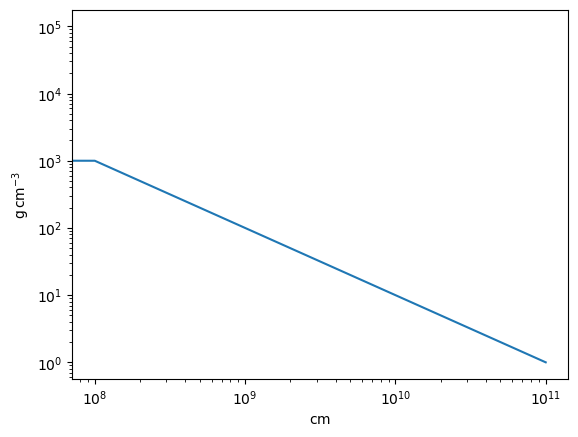

<function mass_profile at 0x75b1921b6ac0>
6.283185302791485e+33 g


<Quantity 2.63490802e+15 Pa>

In [ ]:
rho = 1.5 * u.g/u.cm**3
rho_c = 1e5 * u.g/u.cm**3
rho_R0 = 1 * u.g/u.cm**3
R = 1e11 * u.cm

# Assuming density profile is constant, the calculation of mass for the star is given by:
# integral(0,R) of (4 * np.pi * r*2 * rho) * dV
# 4 * np.pi * R*2 * rho * V

def spherical_volume(R):
    """
    Calculates the volume of a sphere given a radius.
    """
    return 4/3 * R**3 * np.pi


def central_pressure(M,R):
    return ((const.G.value * M**2) / ( R **4))

# part a.)

M = rho * spherical_volume(R)
print('mass of star is ', M)

print(central_pressure(M,R))

# part b.)

def density_profile(r,R,rho_c,rho_R0):
    denom = rho_c/np.sqrt(1+(rho_c**2-rho_R0**2)/(rho_R0**2)*(r/R)**2)
    return rho_c/denom

density_profile = lambda x: rho_c/np.sqrt(1+(rho_c**2-rho_R0**2)/(rho_R0**2)*(x/R)**2)

radius_range = np.linspace(0,R,1000)
density_profile_range = density_profile(radius_range)

plt.plot(radius_range,density_profile_range)
plt.yscale('log')
plt.xscale('log')
plt.show()

def mass_profile(x):
    return 4 * np.pi * x**2 * rho_c/np.sqrt(1+((rho_c**2-rho_R0**2)/(rho_R0**2))*(x/R)**2)
print(mass_profile)
mass_profile_range = mass_profile(radius_range)
total_mass = np.trapezoid(x=radius_range, y=mass_profile_range)
print(total_mass)

real_central_pressure = ((const.G * total_mass.to(u.g)**2) / ( R **4))
real_central_pressure = real_central_pressure.to(u.Pa)


In [51]:
a0 = (4*const.sigma_sb)/const.c
temp = ((3*real_central_pressure*const.c)/(4*const.sigma_sb))**(1/4)
temp.to(u.K)

<Quantity 56853724.71985 K>

### Thurs Feb 5

Original fit parameter:  0.9980224430174455


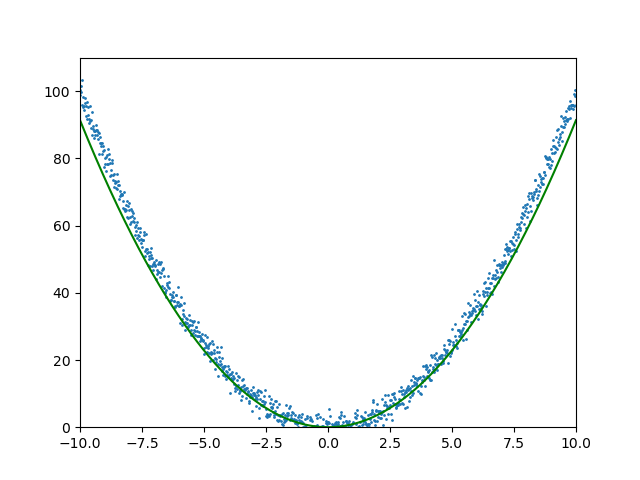

In [20]:
def parabolic(x,a):
    return a*x**2

original_x = np.linspace(-10,10,1000)
original_y = parabolic(original_x,1)
noisy_y = original_y + np.random.normal(0,2,size=original_y.shape)
#plt.scatter(original_x,original_y,s=1)
plt.scatter(original_x,noisy_y,s=1)

popt,pcov = scipy.optimize.curve_fit(parabolic,original_x,noisy_y)
#plt.plot(original_x,parabolic(original_x,popt[0]),c='r')
original_fit_param = popt[0]
print('Original fit parameter: ', original_fit_param)
randomized_params = original_fit_param + np.random.normal(0,0.1,size=1000)
fig,ax = plt.subplots()
plt.scatter(original_x,noisy_y,s=1)
line = ax.plot(original_x,parabolic(original_x,randomized_params[0]),c='g',alpha=1)[0]
def animate(frame):
    y = parabolic(original_x,randomized_params[frame])
    line.set_ydata(y)
    line.set_xdata(original_x)
    return line
ax.set_xlim(-10,10)
ax.set_ylim(0,110)
ani = animation.FuncAnimation(fig, animate, frames=100, interval=50, blit=False,repeat=True)


/home/lkoo/miniconda3/envs/FlareResearch/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


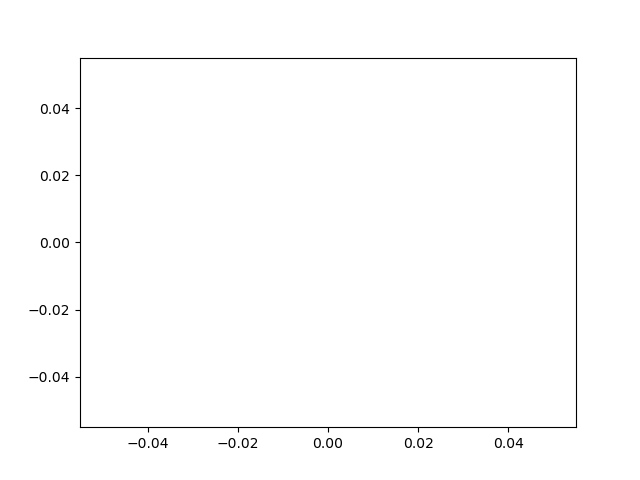

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()
xdata, ydata = [], []
ln, = ax.plot([], [], 'ro')

def init():
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(-1, 1)
    return ln,

def update(frame):
    xdata.append(frame)
    ydata.append(np.sin(frame))
    ln.set_data(xdata, ydata)
    return ln,

ani = FuncAnimation(fig, update, frames=np.linspace(0, 2*np.pi, 128),
                    init_func=init, blit=True)
plt.show()

### Tues Feb 10

In [2]:
def EOSIdealGas(rho,T):
    k_B = const.k_B
    mu = 2.016 * u.g/u.mol
    m_h = 1.007 * u.mol
    return (rho * k_B * T * 1/(mu * m_h))

def spherical_volume(R):
    """
    Calculates the volume of a sphere given a radius.
    """
    return 4/3 * R**3 * np.pi

rho_Sun = 1*u.M_sun/spherical_volume(1*u.R_sun)

EOSIdealGas(rho_Sun,3000*u.K).to(u.Pa)

<Quantity 2.87631092e-14 Pa>

In [3]:
core_pressure = const.G * (1*u.M_sun**2)/(1*u.R_sun**4)
core_pressure.to(u.Pa)

<Quantity 1.12649568e+15 Pa>

In [4]:
current_lum = 1*u.L_sun
current_lum.to(u.J/u.s)
current_mass = 1*u.M_sun

# Goal: Find the luminosity of the sun 5 billion years ago.
# What do I have?
# Current values: Luminosity, Mass, Radius, and Age.
# What do I need to get the luminosity 5 billion years ago? 
# Use the current energy released per second to calculate how much hydrogen was fused per second. Work backwards to see how much mass was lost.

ageofsun = 5*1e9 * 86400 * 365 * u.s

#total energy released was:
E_tot = ageofsun*current_lum
E_tot.to(u.J)

def energy_to_mass(E):
    """
    Converts energy into mass equivalent.

    """
    return E / const.c ** 2

energy_to_mass(E_tot).to(u.kg)

# The problem with this method is that we are assuming that the sun's rate of fusion was constant throughout its life,
# which contradicts the whole point of the minilab. We want to see *IF* the sun's luminosity changed, but we are assuming
# that the luminosity was constant, and therefore the mass loss was constant. We can't do that.



<Quantity 6.71594506e+26 kg>

In [5]:
# Luminosity function
def SolarLuminosity(r,rho,epsilon):
    """
    Calculates Solar Luminosity, given radius, density, and epsilon.
    r (meters): Radius of star in question
    rho (g/meters): Density of star.
    epsilon (J/s): Energy Generation Rate.
    """
    return (4*np.pi *rho * epsilon * (r**3/3))

# Since we are dealing with a main sequence star, we assume that PP-Chain will be the dominant energy generation process. 
# According to Salpeter 1952:

epsilon = 1.26 * 10**19 * u.erg/u.g/u.s

lum = SolarLuminosity(r=u.R_sun,rho=rho_Sun,epsilon=epsilon)
lum.to(u.L_sun)

# This value is much too high. ~19 orders of magnitude too high. This is probably due to the fact that I'm trying to circumvent the differential form of the luminosity equation.
# I'll just do it normally.

<Quantity 6.54492277e+18 solLum>

In [6]:
# Let's assume the star is in hydrostatic equilibrium with it's environment. This means that the pressure exerted by the core is equal to the pressure of gravity.

core_pressure.to(u.Pa)

<Quantity 1.12649568e+15 Pa>

mass of star is  6.283185307179586e+33 g
26349080261676.273 g2 / cm4


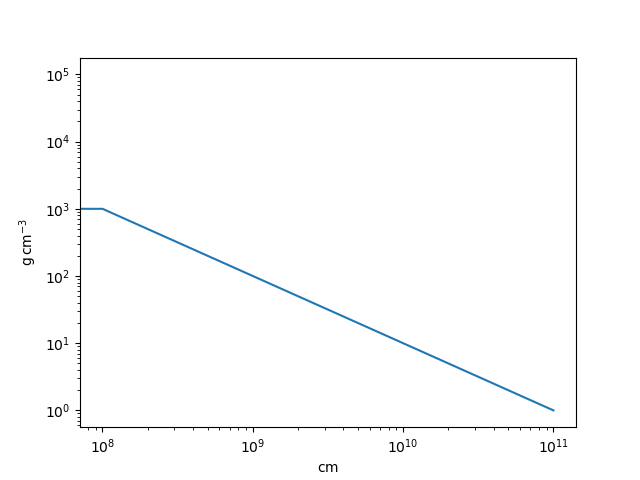

<function mass_profile at 0x7897134c8180>
6.283185302791485e+33 g


In [7]:
rho = 1.5 * u.g/u.cm**3
rho_c = 1e5 * u.g/u.cm**3
rho_R0 = 1 * u.g/u.cm**3
R = 1e11 * u.cm

# Assuming density profile is constant, the calculation of mass for the star is given by:
# integral(0,R) of (4 * np.pi * r*2 * rho) * dV
# 4 * np.pi * R*2 * rho * V

def spherical_volume(R):
    """
    Calculates the volume of a sphere given a radius.
    """
    return 4/3 * R**3 * np.pi


def central_pressure(M,R):
    return ((const.G.value * M**2) / ( R **4))

# part a.)

M = rho * spherical_volume(R)
print('mass of star is ', M)

print(central_pressure(M,R))

# part b.)

def density_profile(r,R,rho_c,rho_R0):
    denom = rho_c/np.sqrt(1+(rho_c**2-rho_R0**2)/(rho_R0**2)*(r/R)**2)
    return rho_c/denom

density_profile = lambda x: rho_c/np.sqrt(1+(rho_c**2-rho_R0**2)/(rho_R0**2)*(x/R)**2)

radius_range = np.linspace(0,R,1000)
density_profile_range = density_profile(radius_range)
plt.close()
plt.plot(radius_range,density_profile_range)
plt.yscale('log')
plt.xscale('log')
plt.show()

def mass_profile(x):
    return 4 * np.pi * x**2 * rho_c/np.sqrt(1+((rho_c**2-rho_R0**2)/(rho_R0**2))*(x/R)**2)
print(mass_profile)
mass_profile_range = mass_profile(radius_range)
total_mass = np.trapezoid(x=radius_range, y=mass_profile_range)
print(total_mass)

real_central_pressure = ((const.G * total_mass.to(u.g)**2) / ( R **4))
real_central_pressure = real_central_pressure.to(u.Pa)


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

/tmp/ipykernel_282994/3831810471.py:13: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  grid = scipy.integrate.quad(pressure_profile,0,R_SUN.value)


ValueError: x and y must have same first dimension, but have shapes (2,) and (1000,)

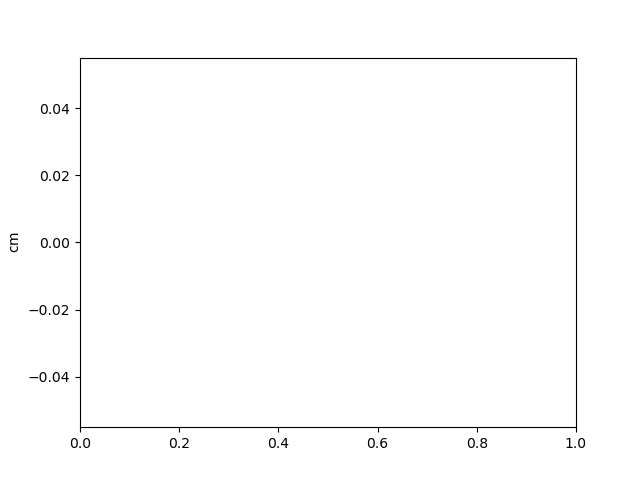

In [ ]:


#Define grid and initial conditions
R_SUN = 1 * u.R_sun
R_SUN = R_SUN.to(u.cm)
M_SUN = 1 * u.M_sun
M_SUN = M_SUN.to(u.g)
r = np.linspace(R_SUN,0,1000)
G = const.G.to(u.cm**3/(u.g*u.s**2))
rho = rho_Sun.to(u.g/u.cm**3)
pressure_profile = lambda r:(-rho.value*G.value*M_SUN.value*(1/r**2))
init = [0] * u.Pa
grid = np.zeros(1000)
print(grid)
grid = scipy.integrate.quad(pressure_profile,0,R_SUN.value)


for i in range(0,len(grid)):

fig,ax = plt.subplots()
plt.plot(grid,r)

#ani.save('test.mp4',fps=3)